# Composite (Addition + Subtraction) Judge Analysis

In [5]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = Path('composite_runs')
REPORT_FILES = sorted(DATA_DIR.glob('*.json'))
REPORT_FILES

[PosixPath('composite_runs/Qwen_Qwen3-0.6B_seed13.json'),
 PosixPath('composite_runs/Qwen_Qwen3-0.6B_seed21.json'),
 PosixPath('composite_runs/Qwen_Qwen3-0.6B_seed37.json'),
 PosixPath('composite_runs/Qwen_Qwen3-1.7B_seed13.json'),
 PosixPath('composite_runs/Qwen_Qwen3-1.7B_seed21.json'),
 PosixPath('composite_runs/Qwen_Qwen3-1.7B_seed37.json'),
 PosixPath('composite_runs/Qwen_Qwen3-4B_seed13.json'),
 PosixPath('composite_runs/Qwen_Qwen3-4B_seed21.json'),
 PosixPath('composite_runs/Qwen_Qwen3-4B_seed37.json'),
 PosixPath('composite_runs/Qwen_Qwen3-8B_seed13.json'),
 PosixPath('composite_runs/Qwen_Qwen3-8B_seed21.json'),
 PosixPath('composite_runs/Qwen_Qwen3-8B_seed37.json'),
 PosixPath('composite_runs/meta-llama_Llama-3.1-8B-Instruct_seed13.json'),
 PosixPath('composite_runs/meta-llama_Llama-3.1-8B-Instruct_seed21.json'),
 PosixPath('composite_runs/meta-llama_Llama-3.1-8B-Instruct_seed37.json'),
 PosixPath('composite_runs/microsoft_Phi-4-mini-instruct_seed13.json'),
 PosixPath('composi

In [ ]:
records = []
for path in REPORT_FILES:
    with path.open() as f:
        report = json.load(f)
    model_name = path.stem.split('_seed')[0].replace('_', '/', 1)
    seed_str = path.stem.split('_seed')[-1]
    seed = int(seed_str) if seed_str.isdigit() else None
    for split in report['splits']:
        records.append({
            'model': model_name,
            'seed': seed,
            'split': split['name'],
            'accuracy': split['accuracy'],
            'std': split['std'],
            'examples': split['num_examples'],
            'unresolved': split['num_unresolved'],
            'report_path': path.as_posix(),
        })

df = pd.DataFrame(records)
df.sort_values(['model', 'seed', 'split'], inplace=True)
df.head()

,model,seed,split,accuracy,std,examples,unresolved,report_path
0,Qwen/Qwen3-0.6B,13,addition,0.430,0.495323,1000,0,composite_runs/Qwen_Qwen3-0.6B_seed13.json
2,Qwen/Qwen3-0.6B,13,composite,0.500,0.500250,1000,0,composite_runs/Qwen_Qwen3-0.6B_seed13.json
1,Qwen/Qwen3-0.6B,13,subtraction,0.501,0.500249,1000,0,composite_runs/Qwen_Qwen3-0.6B_seed13.json
3,Qwen/Qwen3-0.6B,21,addition,0.417,0.493310,1000,0,composite_runs/Qwen_Qwen3-0.6B_seed21.json
5,Qwen/Qwen3-0.6B,21,composite,0.500,0.500250,1000,0,composite_runs/Qwen_Qwen3-0.6B_seed21.json


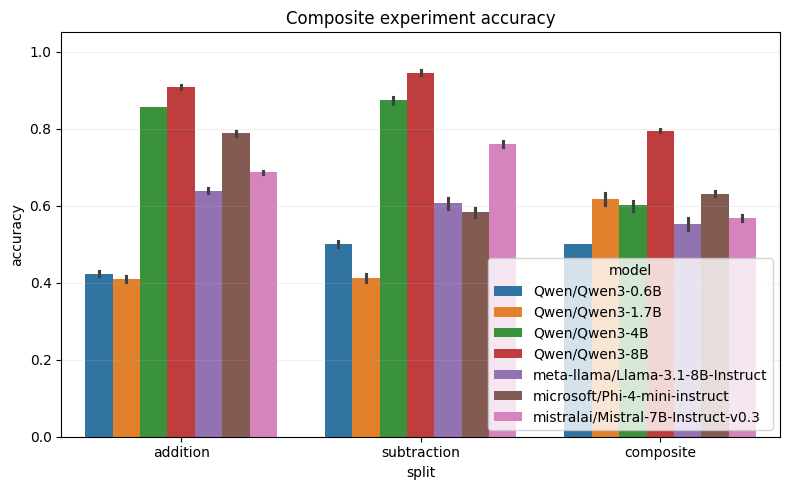

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="split",
    y="accuracy",
    hue="model",
    order=["addition", "subtraction", "composite"],
)
plt.title("Composite experiment accuracy")
plt.ylim(0, 1.05)
plt.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


split,model,addition,subtraction,composite,addition_x_subtraction
0,Qwen/Qwen3-0.6B,0.423333,0.500333,0.500000,0.211808
1,Qwen/Qwen3-1.7B,0.408667,0.411667,0.616667,0.168234
2,Qwen/Qwen3-4B,0.855667,0.875333,0.601000,0.748994
3,Qwen/Qwen3-8B,0.908000,0.945667,0.793667,0.858665
4,meta-llama/Llama-3.1-8B-Instruct,0.637667,0.606667,0.552333,0.386851
5,microsoft/Phi-4-mini-instruct,0.787667,0.582667,0.631333,0.458947
6,mistralai/Mistral-7B-Instruct-v0.3,0.686333,0.759333,0.567000,0.521156


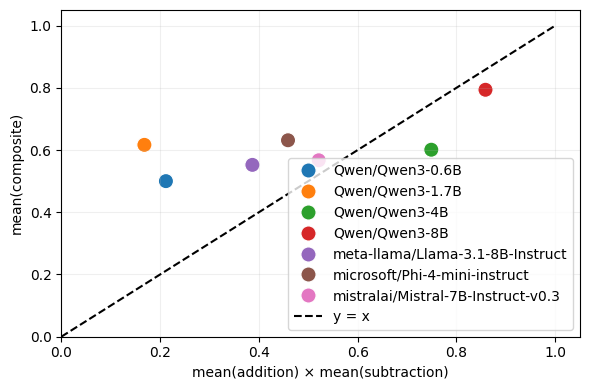

In [10]:
# Aggregate across seeds and compare mean(add × sub) vs mean(composite)
summary = (
    df.groupby(["model", "split"])["accuracy"]
      .mean()
      .unstack("split")[["addition", "subtraction", "composite"]]
      .dropna()
      .reset_index()
)

summary["addition_x_subtraction"] = summary["addition"] * summary["subtraction"]

display(summary)

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=summary,
    x="addition_x_subtraction",
    y="composite",
    hue="model",
    s=120,
)
plt.plot([0, 1], [0, 1], "k--", label="y = x")
plt.xlabel("mean(addition) × mean(subtraction)")
plt.ylabel("mean(composite)")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(alpha=0.2)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
